## Homework 5


Name: Acamaro Cutcher

Comments for instructor/grader:


### 1. Partial derivatives - Electric field of a charge distribution

(Exercise 5.21 in first edition, 5.24 in second)

In **Part a** of this problem, you will write a program that calculates and plots the electric potential from two point charges. In **Part b** you will calculate the partial derivatives of the potential and plot the electric field from this charge distribution.

In two dimensions, the electric potential at point $(x,y$) from a point charge $q$ at the origin is

$$
\phi(x,y) = \frac{q}{4\pi\epsilon_0 (x^2+y^2)^{1/2}},
$$

and the electric field at $(x,y)$ is

$$
{\vec E(x,y)} = -\vec\nabla\phi,
$$

where
$$
\vec\nabla = (\frac{\partial}{\partial x}, \frac{\partial}{\partial y}).
$$

**a)**
Write a program that places two point charges, $q_1, q_2 = \pm1 \mu$ C, inside a square box of length $2\mu$ m.  Prompt the user for the location of each charge inside this box. Calculate and plot the 2D potential map from this charge distribution inside the box. Put the origin in the middle of the box.

Test your program by placing the charges at:

$q_1=-1\mu C: x_1=-0.5\mu m, y_1=0$

$q_2=1\mu C: x_2=+0.5\mu m, y_2=0$
  
  
**Notes**

* You will need to set the keywords vmin, vmax in the *plt.imshow()* to adequately visualize the potential field.
* Label the axes of your plot with the correct physical units.
* Include a colorbar with a label that includes the correct units of your plot.

  

Potential Map Charge Distribution!
Please enter the sign of the first charge (+1 or -1):-1
Please input Charge 1's x position in micro meters: -0.5
Please input Charge 1's y position in micro meters: 0
Please enter the sign of the second charge (+1 or -1):+1
Please input Charge 2's x position in micro meters: 0.5
Please input Charge 2's y position in micro meters: 0


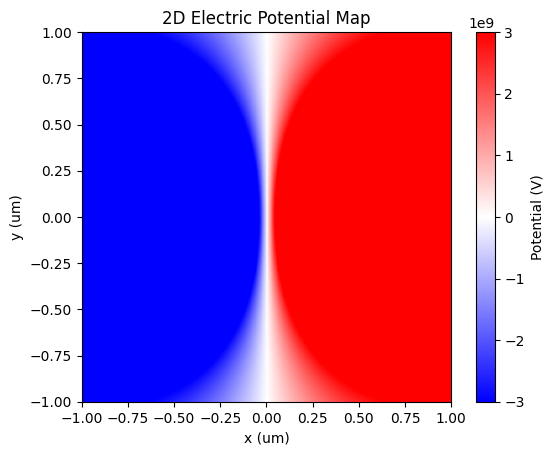

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import epsilon_0, micro
from matplotlib.colors import SymLogNorm

def potential_func(q, X, Y, x0, y0):
    r = np.sqrt((X - x0)**2 + (Y - y0)**2)
    # To avoid division by zero at the charge location, we can set a small non-zero minimum radius
    r[r < 1e-12] = 1e-12 # small number to avoid division by zero
    return q / ( 4 * np.pi * epsilon_0 * r)


def run():

    # User Input
    print("Potential Map Charge Distribution!")
    q_1 = float(input("Please enter the sign of the first charge (+1 or -1):"))*micro   # micro Columb
    x1_position = float(input("Please input Charge 1's x position in micro meters: "))*micro
    y1_position = float(input("Please input Charge 1's y position in micro meters: "))*micro
    q_2 = float(input("Please enter the sign of the second charge (+1 or -1):"))*micro  # micro Columb
    x2_position = float(input("Please input Charge 2's x position in micro meters: "))*micro
    y2_position = float(input("Please input Charge 2's y position in micro meters: "))*micro


    # Mesh Grid
    x = np.linspace(-1*micro, +1*micro, 300)
    y = np.linspace(-1*micro, +1*micro, 300)

    X,Y = np.meshgrid(x,y)

    # Potential Plot
    potential_grid = potential_func(q_1, X, Y, x1_position, y1_position) + potential_func(q_2, X, Y, x2_position, y2_position)


    plt.imshow(potential_grid, vmin=-3e9, vmax=3e9, cmap='bwr', origin='lower', extent=(x.min()/micro, x.max()/micro, y.min()/micro, y.max()/micro))
    plt.xlabel('x (um)')
    plt.ylabel('y (um)')
    plt.title('2D Electric Potential Map')
    plt.colorbar(label='Potential (V)')
    plt.show()

    return potential_grid, X, Y, x, y

# Call run to get the potential grid and coordinates for part b
potential_grid, X, Y, x, y = run()

**Pts /10**

**b)** Now calculate the $x$ and $y$ components of the electric field by finding the numerical partial derivatives of the potential with respect to $x$ and $y$ and hence find the electric field in the $xy$-plane. Although you could calculate the derivatives analytically, the point of this problem is to practice coding numerical partial derivatives.

Make a visualization of the electric field.  This is a little trickier than visualizing the potential, because the electric field has both magnitude and direction.  One way to do this is to make two density plots, one for the magnitude, and one for the direction, the latter using the _"hsv"_ color scheme, which is a rainbow scheme that passes through all the colors but starts and ends with the same shade of red, which makes it suitable for representing things like directions or angles that go around the full circle and end up where they started.  
  
A second option is to use the *matplotlib.pyplot.quiver()* function (https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.quiver.html). to visualize the field using a grid of arrows. Because the electric field strength is so strong near the charges, you will need some clever method to visualize all the vectors.

Label axes appropriately and include a labeled color bar.

In [3]:
# Type code for 1b here

def e_field(potential_grid, x, y):
    # Calculate the gradient of the potential_grid
    # np.gradient returns (d/dy, d/dx) for a 2D array if the input axes correspond to y and x respectively.
    d_phi_dy, d_phi_dx = np.gradient(potential_grid, y, x)
    # Ex = -d(phi)/dx, Ey = -d(phi)/dy
    Ex = -d_phi_dx
    Ey = -d_phi_dy
    return Ex, Ey

# Calculate electric field components
Ex, Ey = e_field(potential_grid, x, y)

print("Electric field components (Ex, Ey) calculated.")
# You can now proceed with visualization

Electric field components (Ex, Ey) calculated.


### Electric Field Visualization

We will visualize the electric field using a `quiver` plot. This allows us to represent both the direction and magnitude of the electric field at various points. To avoid an overly cluttered plot, especially where the field is very strong near the charges, we will subsample the grid for the quiver plot, showing arrows only at selected points.

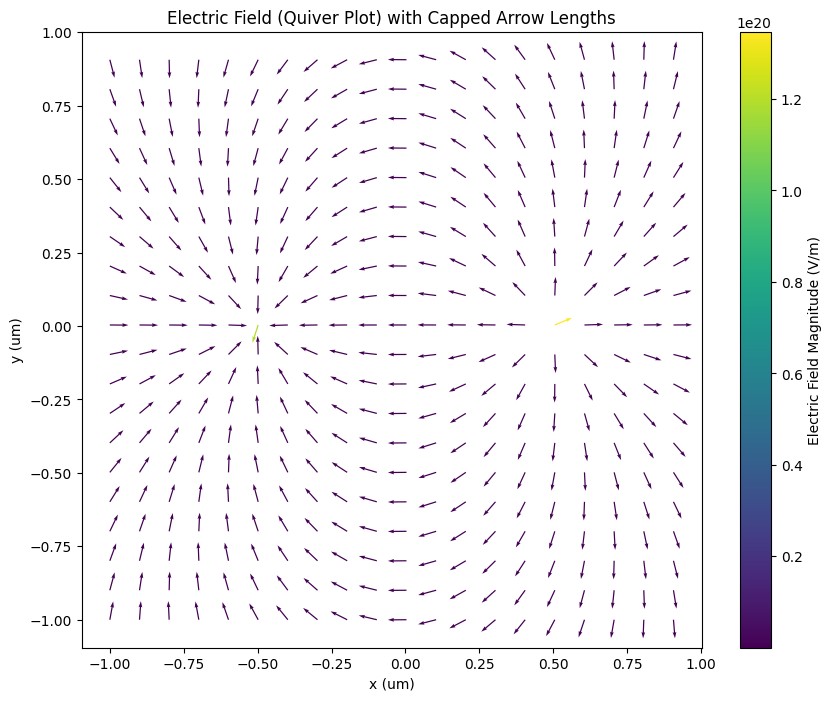

In [24]:
fig = plt.figure(figsize=(10, 8))

# Subsample the grid for visualization to prevent overcrowding, especially near charges
skip = 15 # Plot every 'skip'th arrow

x_sub = x[::skip]
y_sub = y[::skip]
Ex_sub = Ex[::skip, ::skip]
Ey_sub = Ey[::skip, ::skip]

# Calculate true magnitude (used for coloring the arrows)
magnitude = np.sqrt(Ex_sub**2 + Ey_sub**2)

# --- Parameters for arrow length capping ---
# Define a maximum magnitude for arrow length representation.
# Arrows representing fields stronger than this will be capped at this visual length.
max_visual_field_magnitude = 3e15 # Adjust this value as needed

# Calculate capped Ex and Ey components for plotting arrow lengths
# These components will determine the arrow direction and capped length.
scaling_factor = np.ones_like(magnitude)
# For magnitudes greater than max_visual_field_magnitude, scale down the vectors.
scaling_factor[magnitude > max_visual_field_magnitude] = max_visual_field_magnitude / magnitude[magnitude > max_visual_field_magnitude]

Ex_plot = Ex_sub * scaling_factor
Ey_plot = Ey_sub * scaling_factor

# --- Quiver plot parameters ---
quiver_scale = 1e17  # Overall scale factor for arrow lengths (larger value = shorter arrows)
quiver_width = 0.002 # Width of the arrow shafts

plt.quiver(x_sub/micro, y_sub/micro, Ex_plot, Ey_plot, magnitude,
           cmap='viridis', scale=quiver_scale, width=quiver_width)
plt.xlabel('x (um)')
plt.ylabel('y (um)')
plt.title('Electric Field (Quiver Plot) with Capped Arrow Lengths')
plt.colorbar(label='Electric Field Magnitude (V/m)')
plt.show()

**Pts /10**

**Problem 1 Pts: /20**

### 2. Relaxation method

(Exercise 6.10 in first edition, 6.11 in second)

Consider the equation $x = 1 − e^{−cx}$, where $c$ is a known parameter and $x$ is
unknown. This equation arises in a variety of situations, including the physics of contact processes,
mathematical models of epidemics, and the theory of random graphs.

Write a program to solve this equation for $x$ using the relaxation method for values of $c$ from $0$ to $3$ in steps of $0.01$
and make a plot of $x$ as a function of $c$. Calculate your solution to an accuracy of at least $10^{−6}$.

Note there is a trivial solution to the equation at $x=0$, but here we are looking for the non-trivial solution. You should see a clear transition from a regime in which $x = 0$ to a regime of nonzero $x$. This is another example of a phase transition.
In physics this transition is known as the percolation transition; in epidemiology it is the
epidemic threshold.

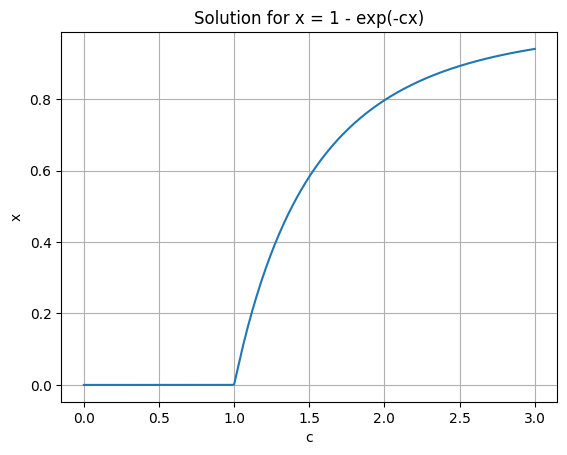

In [28]:
# Type code for relaxation method here here

import numpy as np
import matplotlib.pyplot as plt

def f(x,c):
    return 1 - np.exp(-c* x)

def relaxation_solver(f, x, c):

    flag = 1
    # Start with an initial guess, then apply the function
    x_current = x

    while(flag):
        x_next = f(x_current,c)

        accuracy = np.abs(x_next - x_current)

        if(accuracy < 1e-6):
            flag = 0
        else:
            x_current = x_next
    return x_current


def display():

    c_array = np.arange(0,3.01, 0.01)
    x_initial_guess = 1 # Initial guess for x, avoiding the trivial solution x=0
    x_array = np.array([relaxation_solver(f, x_initial_guess, c) for c in c_array])

    plt.plot(c_array, x_array)
    plt.xlabel('c')
    plt.ylabel('x')
    plt.title('Solution for x = 1 - exp(-cx)')
    plt.grid(True)
    plt.show()

display()

**Problem 2 Pts: /10**

## 3. Particle in a well- Binary search

(Exercise 6.14 in first edition, 6.15 in second)

Consider a square potential well of width $w$, with walls of height $V$:

![exercise_6.14.PNG](attachment:exercise_6.14.PNG)


Using Schr$\ddot{o}$dinger's equation, it can be shown that the allowed
energies $E$ of a single quantum particle of mass $m$ trapped in the well
are solutions of
$
\tan \sqrt{w^2mE/2\hbar^2} = \left\lbrace\begin{array}{ll}
  \sqrt{(V-E)/E} & \qquad\mbox{for the even numbered states,} \\
  - \sqrt{E/(V-E)}  & \qquad\mbox{for the odd numbered states,}
\end{array}\right.
$

where the states are numbered starting from 0, with the ground state being
state 0, the first excited state being state 1, and so forth.

**a)**

 For an electron (mass $9.1094\times10^{-31}\,$kg) in a well with $V =
  20\,$eV and $w = 1\,$nm, write a Python program to plot the three
  quantities

$$
y_1 = \tan \sqrt{w^2mE/2\hbar^2},\qquad
y_2 = \sqrt{V-E\over E},\qquad
y_3 = -\sqrt{E\over V-E},
$$

on the same graph, as a function of $E$ from $E=0$ to $E=20\,$eV.  From
your plot make approximate estimates of the energies of the first six
energy levels of the particle.  Hint: Zoom into your plot about y=0.


/tmp/ipykernel_2415/1205087924.py:18: RuntimeWarning: divide by zero encountered in divide
  result = np.where(condition, np.sqrt((V - E) / E), np.nan)
/tmp/ipykernel_2415/1205087924.py:18: RuntimeWarning: invalid value encountered in sqrt
  result = np.where(condition, np.sqrt((V - E) / E), np.nan)
/tmp/ipykernel_2415/1205087924.py:26: RuntimeWarning: invalid value encountered in sqrt
  result = np.where(condition, -np.sqrt(E / (V - E)), np.nan)


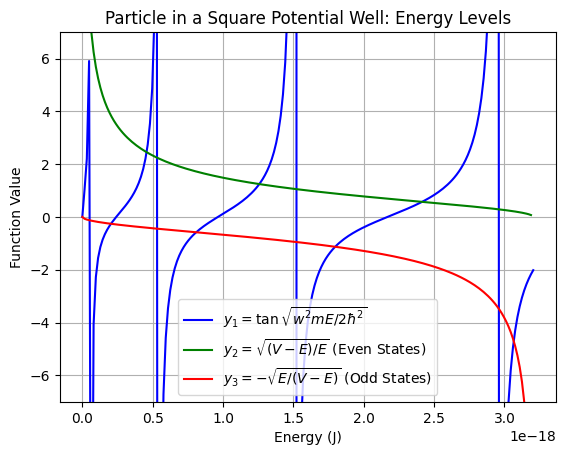

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import eV, m_e, hbar

omega = 1e-9
V = 20 * eV

def y1(E):
    # y1 can have singularities where its argument makes tan undefined (e.g., pi/2, 3pi/2, etc.)
    # These will be handled by matplotlib if they result in inf/nan
    return np.tan(np.sqrt(omega**2 *m_e*E / (2 * hbar**2)))

def y2(E):
    # Valid for E > 0 and V - E >= 0 (i.e., E <= V)
    # So, 0 < E <= V
    condition = (E > 0) & (V - E >= 0)
    # Use np.where to return NaN for invalid points, preventing RuntimeWarnings
    result = np.where(condition, np.sqrt((V - E) / E), np.nan)
    return result

def y3(E):
    # Valid for E >= 0 and V - E > 0 (i.e., E < V)
    # So, 0 <= E < V
    condition = (E >= 0) & (V - E > 0)
    # Use np.where to return NaN for invalid points, preventing RuntimeWarnings
    result = np.where(condition, -np.sqrt(E / (V - E)), np.nan)
    return result

def display():

    E_array = np.arange(0,20*eV + 0.1*eV, 0.1*eV)
    y1_array = y1(E_array)
    y2_array = y2(E_array)
    y3_array = y3(E_array)

    plt.plot(E_array, y1_array, label=r"$y_1 = \tan\sqrt{w^2mE/2\hbar^2}$", color='blue')
    plt.plot(E_array, y2_array, label=r"$y_2 = \sqrt{(V-E)/E}$ (Even States)", color='green')
    plt.plot(E_array, y3_array, label=r"$y_3 = -\sqrt{E/(V-E)}$ (Odd States)", color='red')

    plt.ylim(-7, 7) # Adjust ylim to better visualize intersections around y=0, accommodating both y2 and y3
    plt.xlabel('Energy (J)')
    plt.ylabel('Function Value')
    plt.title('Particle in a Square Potential Well: Energy Levels')
    plt.legend()
    plt.grid(True)
    plt.show()

display()


**Type estimates of energy here:**

**Pts /10**

**b)** Write a second program to calculate the values of the first six
  energy levels in electron volts to an accuracy of $0.001\,$eV using
  binary search. Have your program output the 6 values in units of eV.  Hint. Zoom into your plot to define appropriate initial intervals.



In [50]:
# Part b use binary search to look for roots of even and odd functions
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import eV, m_e, hbar

omega = 1e-9
V = 20 * eV

def y1(E):
    # y1 can have singularities where its argument makes tan undefined (e.g., pi/2, 3pi/2, etc.)
    # These will be handled by matplotlib if they result in inf/nan
    return np.tan(np.sqrt(omega**2 *m_e*E / (2 * hbar**2)))

def y2(E):
    # Valid for E > 0 and V - E >= 0 (i.e., E <= V)
    # So, 0 < E <= V
    condition = (E > 0) & (V - E >= 0)
    # Use np.where to return NaN for invalid points, preventing RuntimeWarnings
    result = np.where(condition, np.sqrt((V - E) / E), np.nan)
    return result

def y3(E):
    # Valid for E >= 0 and V - E > 0 (i.e., E < V)
    # So, 0 <= E < V
    condition = (E >= 0) & (V - E > 0)
    # Use np.where to return NaN for invalid points, preventing RuntimeWarnings
    result = np.where(condition, -np.sqrt(E / (V - E)), np.nan)
    return result

def binary_search(f, x_low, x_high, accuracy=0.001*eV, max_iterations=1000):
    # We assume that f(x_low) and f(x_high) have opposite signs initially
    # and that x_low < x_high.

    # Convert inputs to float to prevent integer division issues with midpoints
    x_low = float(x_low)
    x_high = float(x_high)

    # Ensure the initial interval brackets a root (signs are opposite)
    if np.sign(f(x_low)) == np.sign(f(x_high)):
        # If signs are the same, there might not be a single root or the interval is not valid
        # For this problem, we need to carefully choose initial intervals from the plot.
        print(f"Warning: Initial interval [{x_low:.2e}, {x_high:.2e}] does not bracket a root.")
        return np.nan # Or raise an error

    for _ in range(max_iterations):
        x_mid = (x_low + x_high) / 2.0

        # Check if the interval is smaller than the desired accuracy
        if abs(x_high - x_low) < accuracy:
            return x_mid

        f_mid = f(x_mid)

        # Determine which half of the interval contains the root
        if np.sign(f_mid) == np.sign(f(x_low)):
            x_low = x_mid
        else:
            x_high = x_mid

    print("Warning: Binary search did not converge within max_iterations.")
    return (x_low + x_high) / 2.0

def f_even(E):
    return y1(E) - y2(E)

def f_odd(E):
    return y1(E) - y3(E)

def run():

    x1_low = 0.1
    x1_high = 0.2

    root1 = binary_search(f_even, x1_low, x1_high)

    print("Root 1: ", root1)

    x2_low =  0.01
    x2_high = 0.3

    root2 = binary_search(f_odd, x2_low, x2_high)

    print("Root 2: ", root2)

    x3_low = 0.2
    x3_high = 0.48

    root3 = binary_search(f_even, x3_low, x3_high)

    print("Root 3: ", root3)

    x4_low = 0.55
    x4_high = 1

    root4 = binary_search(f_odd, x4_low, x4_high)

    print("Root 4: ", root4)

    x5_low = 1
    x5_high = 1.4

    root5 = binary_search(f_even, x5_low, x5_high)

    print("Root 5: ", root5)

    x6_low = 1.6
    x6_high = 2

    root6 = binary_search(f_odd, x6_low, x6_high)

    print("Root 6: ", root6)

run()

Root 1:  0.1
Root 2:  0.010000000000000002
Root 3:  0.2
Root 4:  0.55
Root 5:  1.0
Root 6:  1.6


/tmp/ipykernel_2415/2657577470.py:19: RuntimeWarning: invalid value encountered in sqrt
  result = np.where(condition, np.sqrt((V - E) / E), np.nan)
/tmp/ipykernel_2415/2657577470.py:27: RuntimeWarning: invalid value encountered in sqrt
  result = np.where(condition, -np.sqrt(E / (V - E)), np.nan)


**Pts /10**

**Problem 3 Pts /20**

##  4. Lagrange point - Newton's method
(Exercise 6.16 from first edition, 6.17 in second)

There is a magical point between the Earth and the Moon, called the $L_1$ Lagrange point, at which a satellite will orbit the Earth in perfect synchrony with the Moon, staying always in between the two.  This works because the inward pull of the Earth and the outward pull of the Moon combine to create exactly the needed centripetal force that keeps the satellite in its orbit. See diagram below.

**a)** Assuming circular orbits, and assuming that the Earth is much more massive than either the Moon or the satellite, show that the distance $r$ from the center of the Earth to the $L_1$ point satisfies

\begin{equation*}
{GM\over r^2} - {Gm\over(R-r)^2} = \omega^2 r,
\end{equation*}

where $M$ and $m$ are the Earth and Moon masses, $G$ is Newton's
gravitational constant, and $\omega$ is the angular velocity of both the
Moon and the satellite.

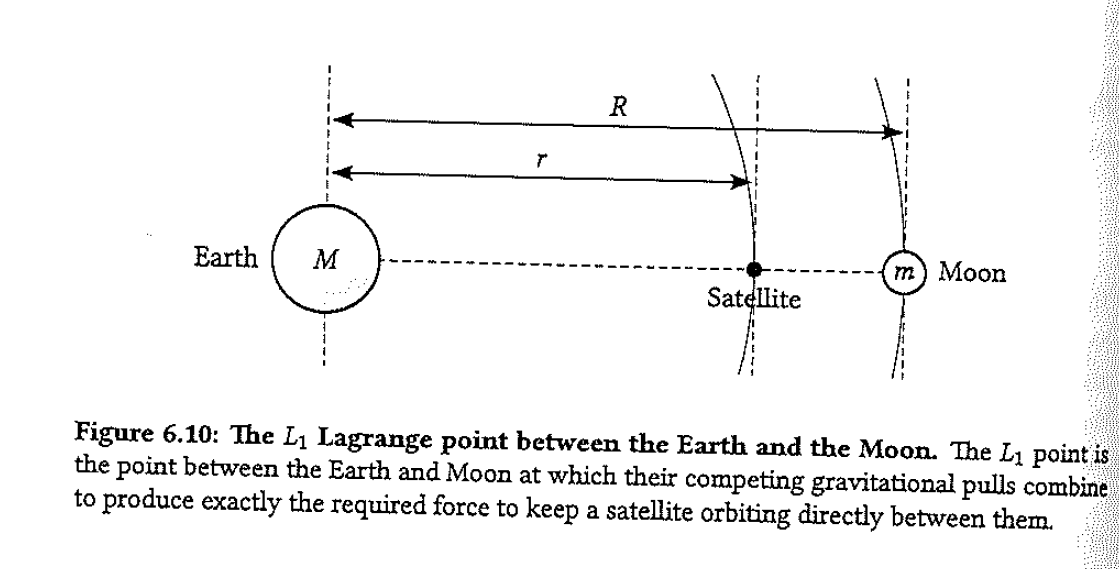

In [ ]:
from IPython.display import Image, display
display(Image("G:\\My Drive\\Classes\\Ph322\\2026\\Homework\\Figures\\fig6.10_lagrange_point.png"))

**Type solution here**



$R$ = distance between centers of mass of Earth and moon

$r$ = distance from center of mass of Earth and satellite

$m_s$ = mass of satellite

$M$ = mass of earth

$m$ = mass of moon


**Pts /5**

**b)** The equation above is a fifth-order polynomial equation in $r$ (also called a quintic equation).  Such equations cannot be solved exactly in closed form, but it's straightforward to solve them numerically.  Write a program that uses Newton's method to solve for the distance $r$ from the Earth to the $L_1$ point.  Compute a solution accurate to at least four significant figures.

  The values of the various parameters are:
\begin{align*}
G &= 6.674\times10^{-11}\,\mathrm{m}^3\mathrm{kg}^{-1}\mathrm{s}^{-2}, \\
M &= 5.974\times10^{24}\,\mathrm{kg}, \\
m &= 7.348\times10^{22}\,\mathrm{kg}, \\
R &= 3.844\times10^8\,\mathrm{m}, \\
\omega &= 2.662\times10^{-6}\,\mathrm{s}^{-1}.
\end{align*}
You will also need to choose a suitable starting value for $r$. Think about what value r should be.

$$
\begin{equation*}
{GM\over r^2} - {Gm\over(R-r)^2} = \omega^2 r,
\end{equation*}
$$

In [ ]:
# Type Lagrange problem code here
import numpy as np
from scipy.constants import G
# Variables

M = 5.974e24
m = 7.348e22
R = 3.844e8
omega = 2.662e-6

def f(r):
    return G*M/r**2 - G*m/(R - r)**2 - omega**2 * r

def netwon(f, f_prime, x):
    return x - f(x)/f_prime(x)

def find_zero():
    return



**Pts /10**

**Problem 4 Pts /15**

## Total HW Pts /65

AI use: I used an AI model to help me solve parts of the homework, specifically, the first problem part b). I was not sure how to make the vector plots, and it was really helpful to know what parameters to change to get the arrows just right and to have the arrow lenghts contrained in some manner.